NOTEBOOK 2: Exploratory Data Analysis (EDA)
Run AFTER Notebook 1 is complete.
 
Inputs:
    - capitol_trades_clean.csv
    - all_stocks_clean.csv
 
Outputs:
    - Visual charts
    - eda_summary.csv  (key statistics table for report)
"""

# CELL 1 — Imports & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

TRADES_PATH = os.path.join('data', 'processed', 'cleaned', 'capitol_trades_clean.csv')
STOCKS_PATH = os.path.join('data', 'processed', 'cleaned', 'all_stocks_clean.csv')
OUTPUT_EDA  = os.path.join('data', 'output', 'eda_summary.csv')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
 
trades = pd.read_csv(TRADES_PATH, parse_dates=['trade_date', 'disclosure_date'])
stocks = pd.read_csv(STOCKS_PATH, parse_dates=['date'])
 
print("=" * 55)
print("DATA LOADED")
print(f"  Trades : {len(trades):,} rows  |  {trades['politician'].nunique()} politicians")
print(f"  Stocks : {len(stocks):,} rows  |  {stocks['ticker'].nunique()} tickers")
print(f"  Trade date range : {trades['trade_date'].min().date()} → {trades['trade_date'].max().date()}")
print(f"  Stock date range : {stocks['date'].min().date()} → {stocks['date'].max().date()}")
print("=" * 55)
 

DATA LOADED
  Trades : 26,566 rows  |  150 politicians
  Stocks : 1,254,044 rows  |  1566 tickers
  Trade date range : 2023-04-17 → 2026-03-31
  Stock date range : 2023-01-02 → 2026-12-03


# CELL 2 — Basic Summary Statistics

In [2]:
print("── TRADE OVERVIEW ──────────────────────────────────")
print(f"Total qualifying trades      : {len(trades):,}")
print(f"Unique politicians           : {trades['politician'].nunique()}")
print(f"Unique tickers traded        : {trades['ticker'].nunique()}")
print(f"Unique companies             : {trades['company'].nunique()}")
print(f"House members                : {(trades['chamber'] == 'House').sum():,} trades")
print(f"Senate members               : {(trades['chamber'] == 'Senate').sum():,} trades")
print(f"Buy trades                   : {(trades['trade_type'] == 'BUY').sum():,}")
print(f"Sell trades                  : {(trades['trade_type'] == 'SELL').sum():,}")
print()
print("── BLIND SPOT WINDOW STATS ─────────────────────────")
print(trades['filed_after_days'].describe().round(1).to_string())
print()
print("── SIZE BRACKET DISTRIBUTION ───────────────────────")
size_order = ['1K-15K','15K-50K','50K-100K','100K-250K','250K-500K','500K-1M','1M-5M','5M-25M']
size_counts = trades['size_bracket'].value_counts().reindex(size_order).dropna()
for bracket, count in size_counts.items():
    pct = count / len(trades) * 100
    print(f"  {bracket:<15} {count:>6,}  ({pct:.2f}%)")
 

── TRADE OVERVIEW ──────────────────────────────────
Total qualifying trades      : 26,566
Unique politicians           : 150
Unique tickers traded        : 1676
Unique companies             : 1679
House members                : 24,996 trades
Senate members               : 1,531 trades
Buy trades                   : 12,312
Sell trades                  : 14,254

── BLIND SPOT WINDOW STATS ─────────────────────────
count    26566.0
mean        38.8
std         60.7
min          5.0
25%         19.0
50%         28.0
75%         36.0
max        867.0

── SIZE BRACKET DISTRIBUTION ───────────────────────
  1K-15K          20,355  (76.62%)
  15K-50K          4,285  (16.13%)
  50K-100K         1,146  (4.31%)
  100K-250K          620  (2.33%)
  250K-500K           98  (0.37%)
  500K-1M             37  (0.14%)
  1M-5M               22  (0.08%)
  5M-25M               3  (0.01%)


# CELL 3 — Chart 1: Blind Spot Window Distribution


Filed within 45-day limit  : 91.7%
Filed LATE (>45 days)      : 8.3%
Max blind spot observed    : 867 days


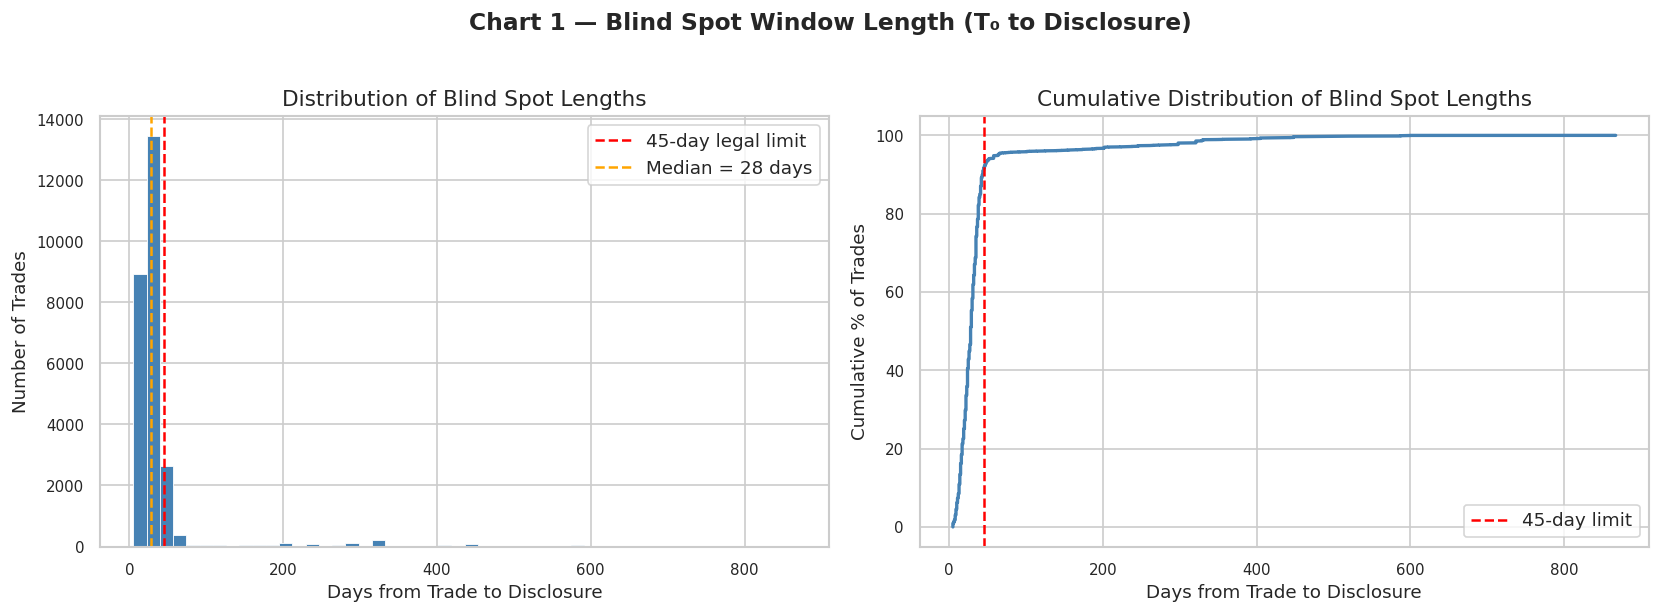

Chart 1 saved to: data/output/chart1_blindspot_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 1 — Blind Spot Window Length (T₀ to Disclosure)",
             fontsize=14, fontweight='bold', y=1.02)
 
#Histogram
ax = axes[0]
ax.hist(trades['filed_after_days'].dropna(), bins=50,
        color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(45, color='red', linestyle='--', linewidth=1.5, label='45-day legal limit')
ax.axvline(trades['filed_after_days'].median(), color='orange',
           linestyle='--', linewidth=1.5,
           label=f"Median = {trades['filed_after_days'].median():.0f} days")
ax.set_xlabel("Days from Trade to Disclosure")
ax.set_ylabel("Number of Trades")
ax.set_title("Distribution of Blind Spot Lengths")
ax.legend()
 
#Cumulative distribution
ax2 = axes[1]
sorted_days = np.sort(trades['filed_after_days'].dropna())
cumulative  = np.arange(1, len(sorted_days) + 1) / len(sorted_days)
ax2.plot(sorted_days, cumulative * 100, color='steelblue', linewidth=2)
ax2.axvline(45, color='red', linestyle='--', linewidth=1.5, label='45-day limit')
ax2.set_xlabel("Days from Trade to Disclosure")
ax2.set_ylabel("Cumulative % of Trades")
ax2.set_title("Cumulative Distribution of Blind Spot Lengths")
ax2.legend()
 
#% filed within 45 days
pct_45 = (trades['filed_after_days'] <= 45).mean() * 100
pct_late = 100 - pct_45
print(f"\nFiled within 45-day limit  : {pct_45:.1f}%")
print(f"Filed LATE (>45 days)      : {pct_late:.1f}%")
print(f"Max blind spot observed    : {trades['filed_after_days'].max():.0f} days")


plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart1_blindspot_distribution.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 1 saved to: {out_path}")

# CELL 4 — Chart 2: Top 20 Most Active Traders

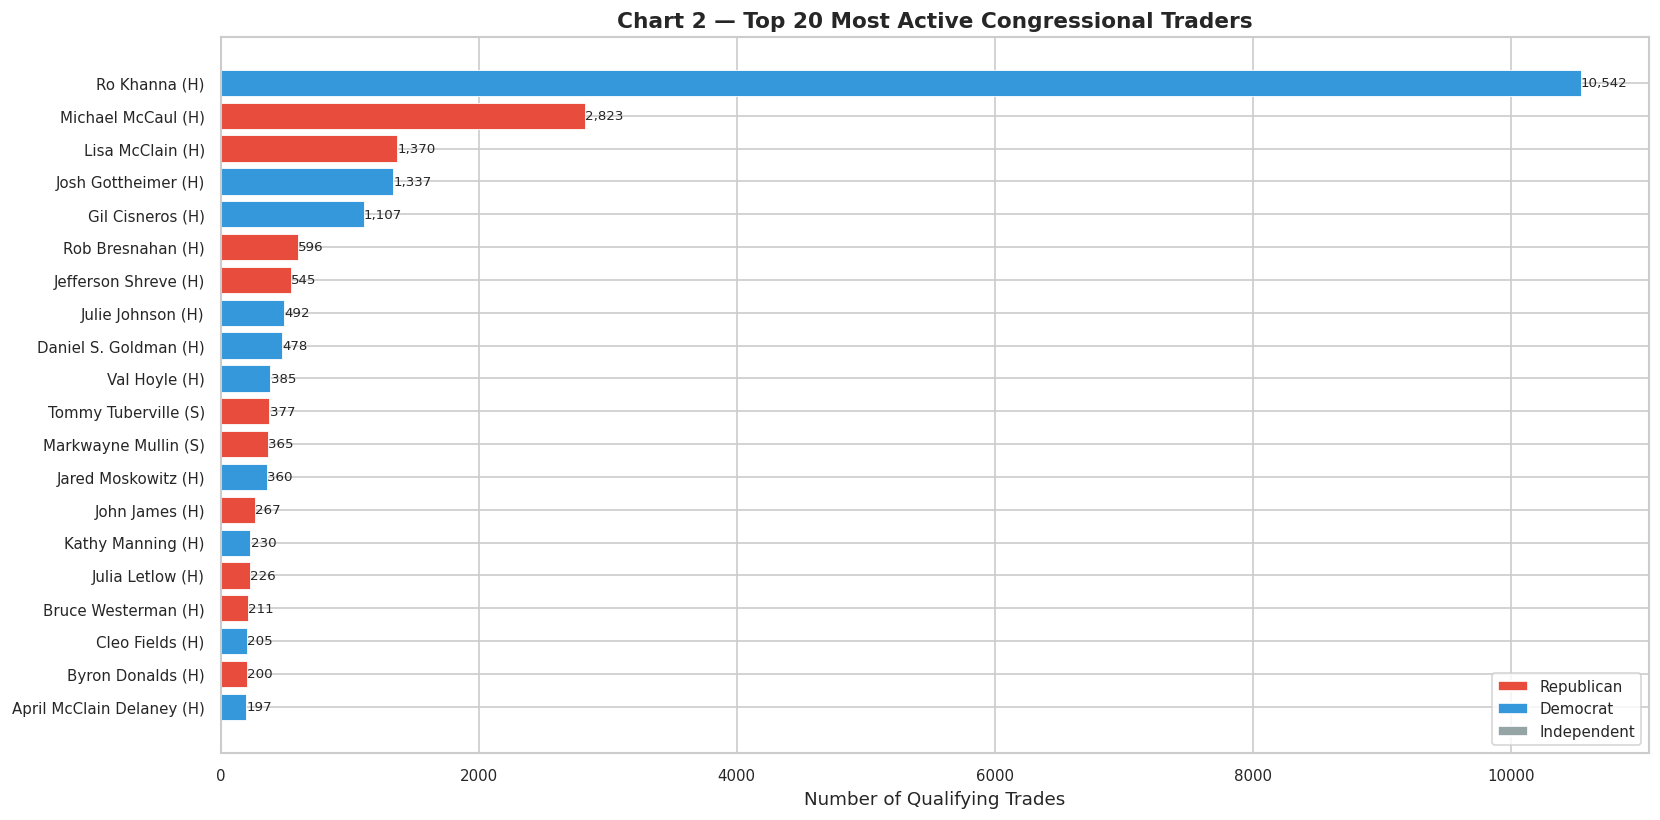

Chart 2 saved to: data/output/chart2_top_traders.png
           politician      party chamber  total_trades
            Ro Khanna   Democrat   House         10542
       Michael McCaul Republican   House          2823
         Lisa McClain Republican   House          1370
      Josh Gottheimer   Democrat   House          1337
         Gil Cisneros   Democrat   House          1107
        Rob Bresnahan Republican   House           596
     Jefferson Shreve Republican   House           545
        Julie Johnson   Democrat   House           492
    Daniel S. Goldman   Democrat   House           478
            Val Hoyle   Democrat   House           385
     Tommy Tuberville Republican  Senate           377
     Markwayne Mullin Republican  Senate           365
      Jared Moskowitz   Democrat   House           360
           John James Republican   House           267
        Kathy Manning   Democrat   House           230
         Julia Letlow Republican   House           226
      Bruce 

In [4]:
top_traders = (
    trades.groupby('politician')
    .agg(
        total_trades=('ticker', 'count'),
        buy_trades=('trade_type_encoded', 'sum'),
        chamber=('chamber', 'first'),
        party=('party', 'first')
    )
    .reset_index()
    .sort_values('total_trades', ascending=False)
    .head(20)
)
top_traders['sell_trades'] = top_traders['total_trades'] - top_traders['buy_trades']
 
# Colour by party
party_colors = {'Republican': '#E74C3C', 'Democrat': '#3498DB', 'Independent': '#95A5A6'}
bar_colors = [party_colors.get(p, '#95A5A6') for p in top_traders['party']]
 
fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(range(len(top_traders)), top_traders['total_trades'],
               color=bar_colors, edgecolor='white', linewidth=0.5)
 
ax.set_yticks(range(len(top_traders)))
ax.set_yticklabels([
    f"{row['politician']} ({row['chamber'][0]})"
    for _, row in top_traders.iterrows()
], fontsize=9)
ax.set_xlabel("Number of Qualifying Trades")
ax.set_title("Chart 2 — Top 20 Most Active Congressional Traders",
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
 
# Add value labels
for bar in bars:
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=8)
 
# Legend for party colours
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=p) for p, c in party_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)



plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart2_top_traders.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 2 saved to: {out_path}")
print(top_traders[['politician', 'party', 'chamber', 'total_trades']].to_string(index=False))

# CELL 5 — Chart 3: Buy vs Sell Split

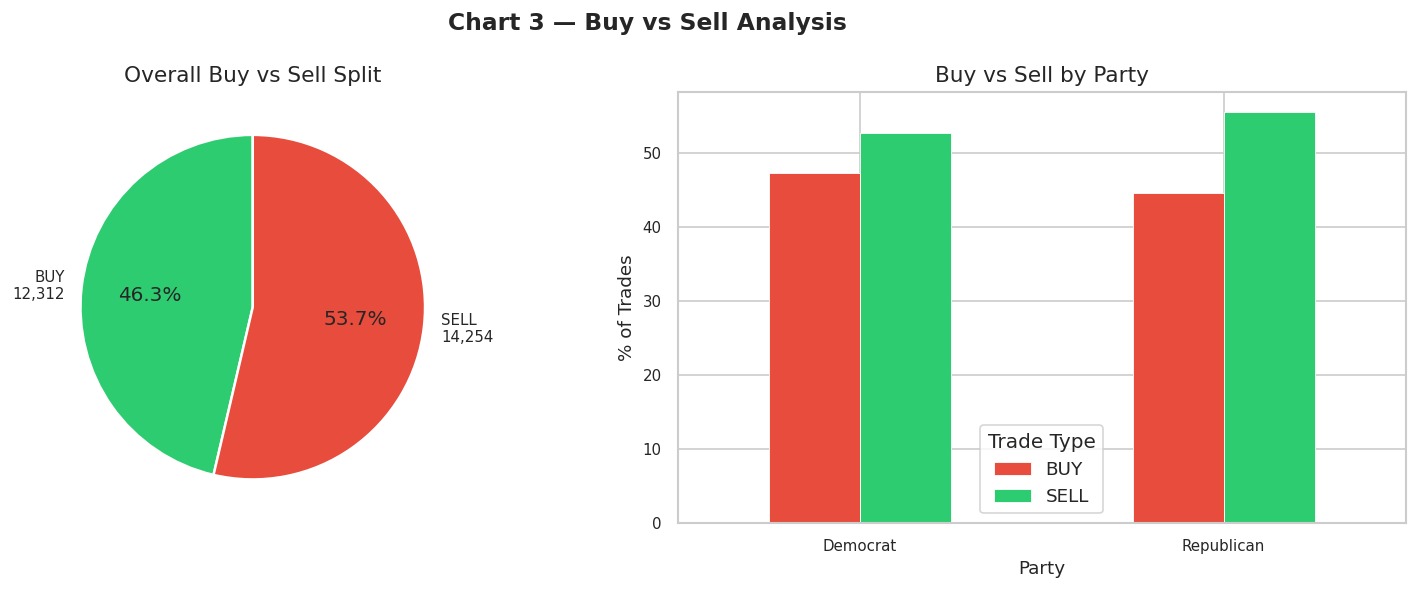

Chart 3 saved to: data/output/chart3_buy_sell.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Chart 3 — Buy vs Sell Analysis", fontsize=14, fontweight='bold')
 
# Left: Overall pie
ax = axes[0]
buy_count  = (trades['trade_type'] == 'BUY').sum()
sell_count = (trades['trade_type'] == 'SELL').sum()
ax.pie([buy_count, sell_count],
       labels=[f'BUY\n{buy_count:,}', f'SELL\n{sell_count:,}'],
       autopct='%1.1f%%',
       colors=['#2ECC71', '#E74C3C'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title("Overall Buy vs Sell Split")
 
# Right: By party
ax2 = axes[1]
party_trade = trades.groupby(['party', 'trade_type']).size().unstack(fill_value=0)
party_trade_pct = party_trade.div(party_trade.sum(axis=1), axis=0) * 100
party_trade_pct.plot(kind='bar', ax=ax2, color=['#E74C3C', '#2ECC71'],
                     edgecolor='white', linewidth=0.5)
ax2.set_xlabel("Party")
ax2.set_ylabel("% of Trades")
ax2.set_title("Buy vs Sell by Party")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title="Trade Type")

plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart3_buy_sell.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 3 saved to: {out_path}")

# CELL 6 — Chart 4: Trade Size Bracket Distribution

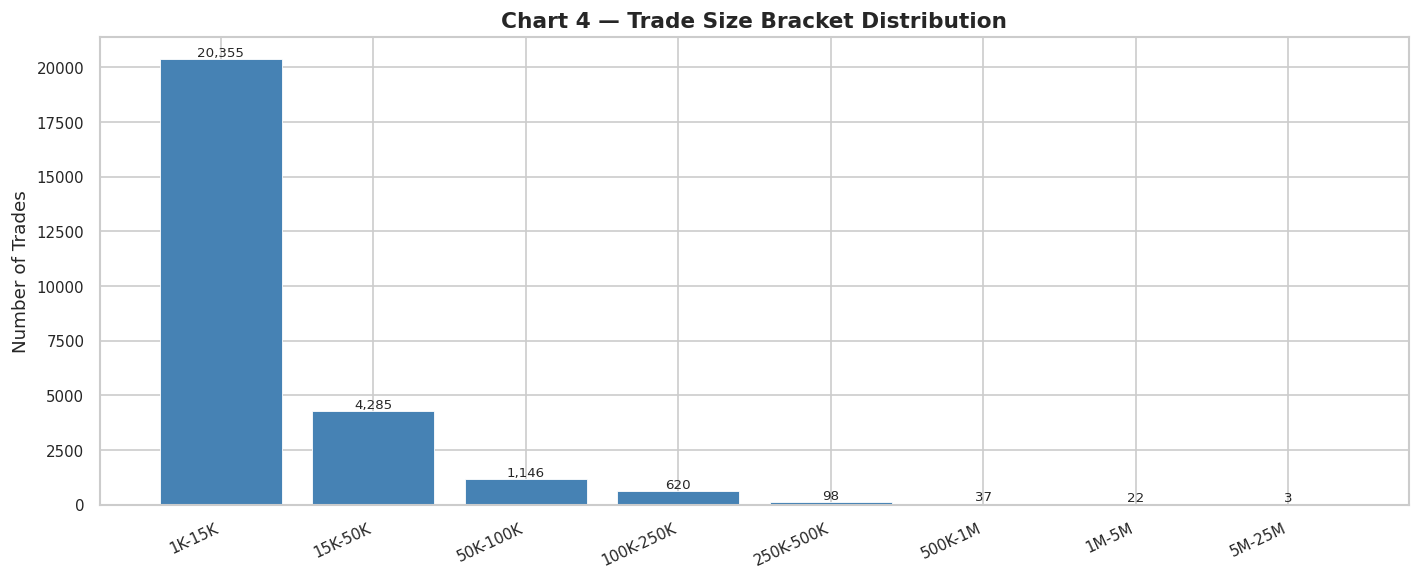

Chart 4 saved to: data/output/chart4_size_brackets.png


In [6]:
size_order = ['1K-15K','15K-50K','50K-100K','100K-250K',
              '250K-500K','500K-1M','1M-5M','5M-25M']
size_counts = trades['size_bracket'].value_counts().reindex(size_order).fillna(0)
 
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(size_counts)), size_counts.values,
              color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_xticks(range(len(size_counts)))
ax.set_xticklabels(size_counts.index, rotation=25, ha='right')
ax.set_ylabel("Number of Trades")
ax.set_title("Chart 4 — Trade Size Bracket Distribution",
             fontsize=13, fontweight='bold')
 
for bar in bars:
    height = int(bar.get_height())
    if height > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, height + 5,
                f"{height:,}", ha='center', va='bottom', fontsize=8)

                



plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart4_size_brackets.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 4 saved to: {out_path}")
 

# CELL 7 — Chart 5: Trades Over Time (Monthly Volume)

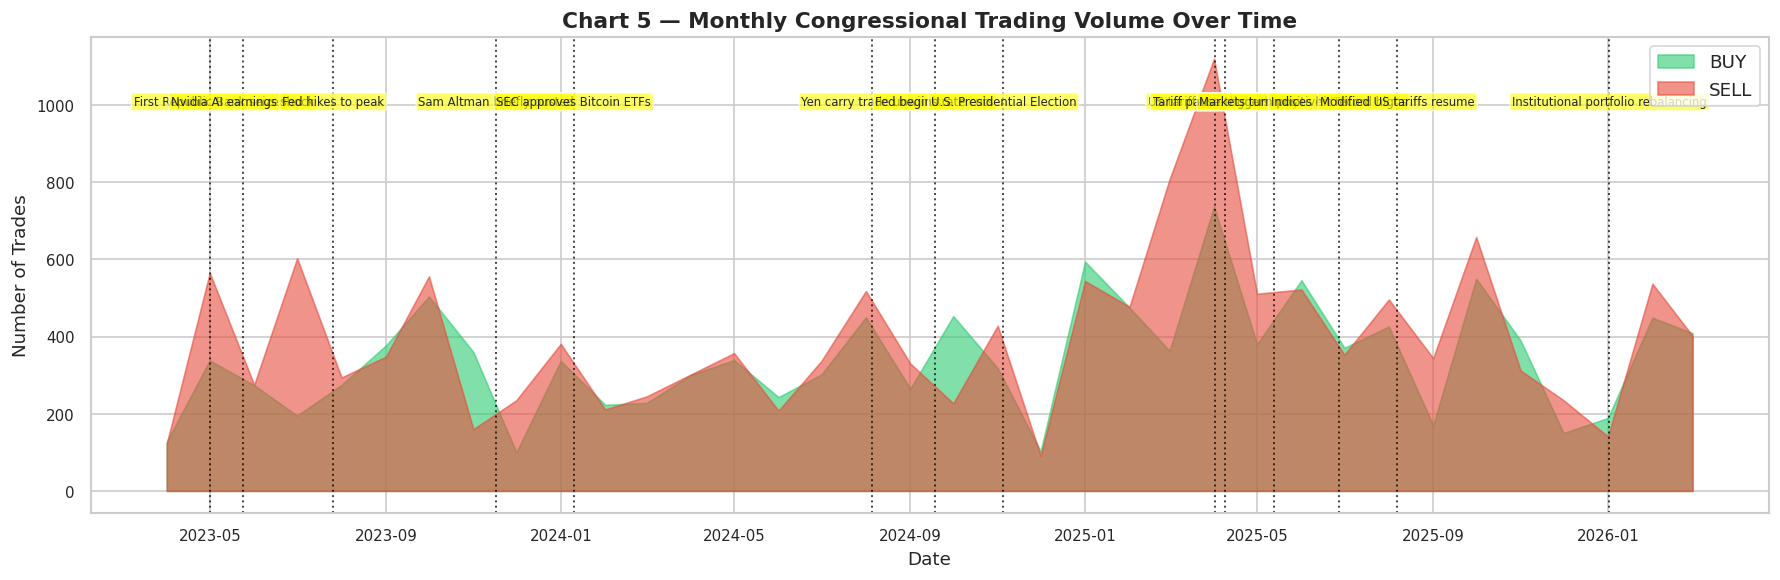

Chart 5 saved to: data/output/chart5_monthly_volume.png


In [7]:
trades['year_month'] = trades['trade_date'].dt.to_period('M')
monthly = trades.groupby(['year_month', 'trade_type']).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()
 
fig, ax = plt.subplots(figsize=(15, 5))
ax.fill_between(monthly.index,
                monthly.get('BUY', 0),
                alpha=0.6, color='#2ECC71', label='BUY')
ax.fill_between(monthly.index,
                monthly.get('SELL', 0),
                alpha=0.6, color='#E74C3C', label='SELL')
ax.set_xlabel("Date")
ax.set_ylabel("Number of Trades")
ax.set_title("Chart 5 — Monthly Congressional Trading Volume Over Time",
             fontsize=13, fontweight='bold')
ax.legend()
 
# Not all events included here, just big ones 
events = {
    # --- 2023 ---
    '2023-05-01': 'First Republic Bank seized',
    '2023-05-24': 'Nvidia AI earnings shock',
    '2023-07-26': 'Fed hikes to peak',
    '2023-11-17': 'Sam Altman briefly ousted',
    
    # --- 2024 ---
    '2024-01-10': 'SEC approves Bitcoin ETFs',
    '2024-08-05': 'Yen carry trade unwinds',
    '2024-09-18': 'Fed begins rate cuts',
    '2024-11-05': 'U.S. Presidential Election',
    
    # --- 2025 ---
    '2025-04-02': 'US tariffs crash market',
    '2025-04-09': 'Tariff pause triggers rally',
    '2025-05-13': 'Markets turn positive YTD',
    '2025-06-27': 'Indices hit record highs',
    '2025-08-07': 'Modified US tariffs resume',
    
    # --- 2026 ---
    '2026-01-02': 'Institutional portfolio rebalancing'
}
for date_str, label in events.items():
    try:
        event_date = pd.Timestamp(date_str)
        if event_date >= monthly.index.min() and event_date <= monthly.index.max():
            ax.axvline(event_date, color='black', linestyle=':', linewidth=1.2, alpha=0.7)
            ax.text(event_date, ax.get_ylim()[1] * 0.85, label,
                    fontsize=7, ha='center',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.6))
    except Exception:
        pass
 




plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart5_monthly_volume.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 5 saved to: {out_path}")

# CELL 8 — Chart 6: Disclosure Delay by Party & Chamber

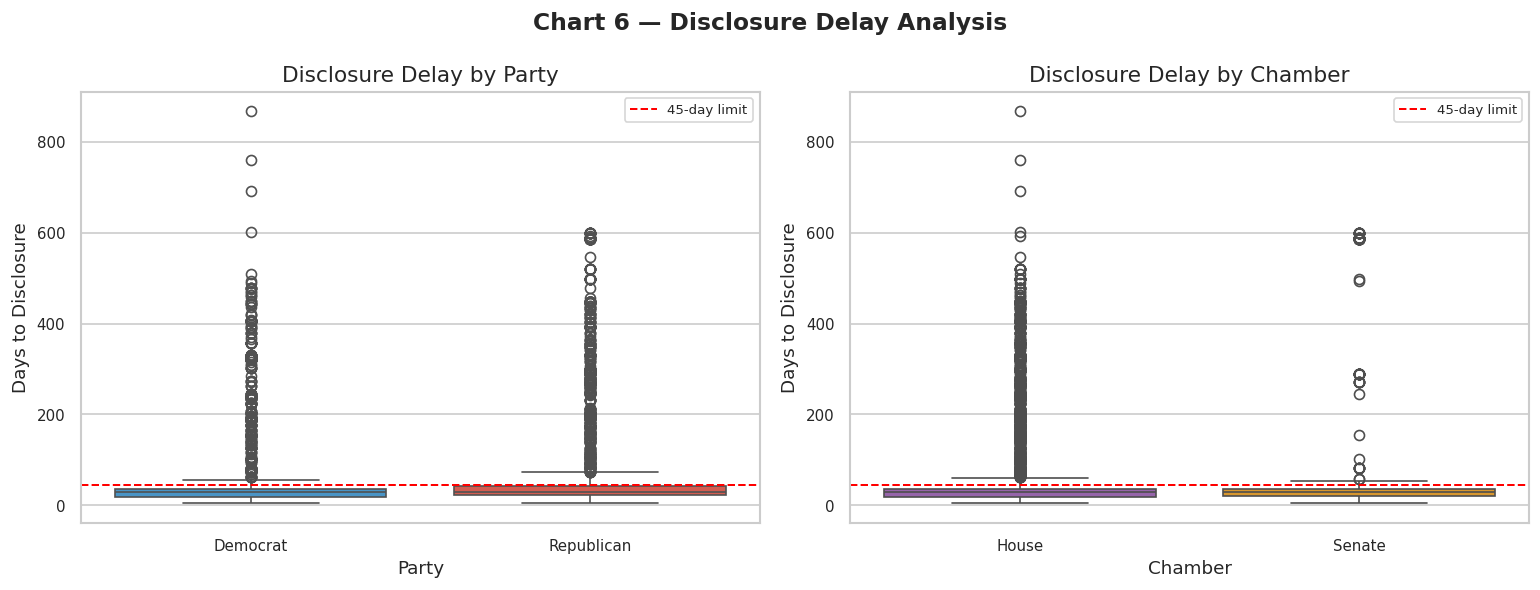

Chart 6 saved to: data/output/chart6_disclosure_delay.png

Median disclosure delay by party:
party
Democrat      28.0
Republican    30.0

Median disclosure delay by chamber:
chamber
House     28.0
Senate    29.0


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Chart 6 — Disclosure Delay Analysis",
             fontsize=14, fontweight='bold')
 
# Left: by party
ax = axes[0]
party_order = trades.groupby('party')['filed_after_days'].median().sort_values().index
sns.boxplot(data=trades, x='party', y='filed_after_days',
            order=party_order, ax=ax,
            palette={'Republican': '#E74C3C', 'Democrat': '#3498DB', 'Independent': '#95A5A6'})
ax.axhline(45, color='red', linestyle='--', linewidth=1.2, label='45-day limit')
ax.set_xlabel("Party")
ax.set_ylabel("Days to Disclosure")
ax.set_title("Disclosure Delay by Party")
ax.legend(fontsize=8)
 
# Right: by chamber
ax2 = axes[1]
sns.boxplot(data=trades, x='chamber', y='filed_after_days',
            order=['House', 'Senate'], ax=ax2,
            palette={'House': '#9B59B6', 'Senate': '#F39C12'})
ax2.axhline(45, color='red', linestyle='--', linewidth=1.2, label='45-day limit')
ax2.set_xlabel("Chamber")
ax2.set_ylabel("Days to Disclosure")
ax2.set_title("Disclosure Delay by Chamber")
ax2.legend(fontsize=8)
 

plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart6_disclosure_delay.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 6 saved to: {out_path}")

# Print median delays
print("\nMedian disclosure delay by party:")
print(trades.groupby('party')['filed_after_days'].median().round(1).to_string())
print("\nMedian disclosure delay by chamber:")
print(trades.groupby('chamber')['filed_after_days'].median().round(1).to_string())

# CELL 9 — Chart 7: Top 20 Most Traded Stocks

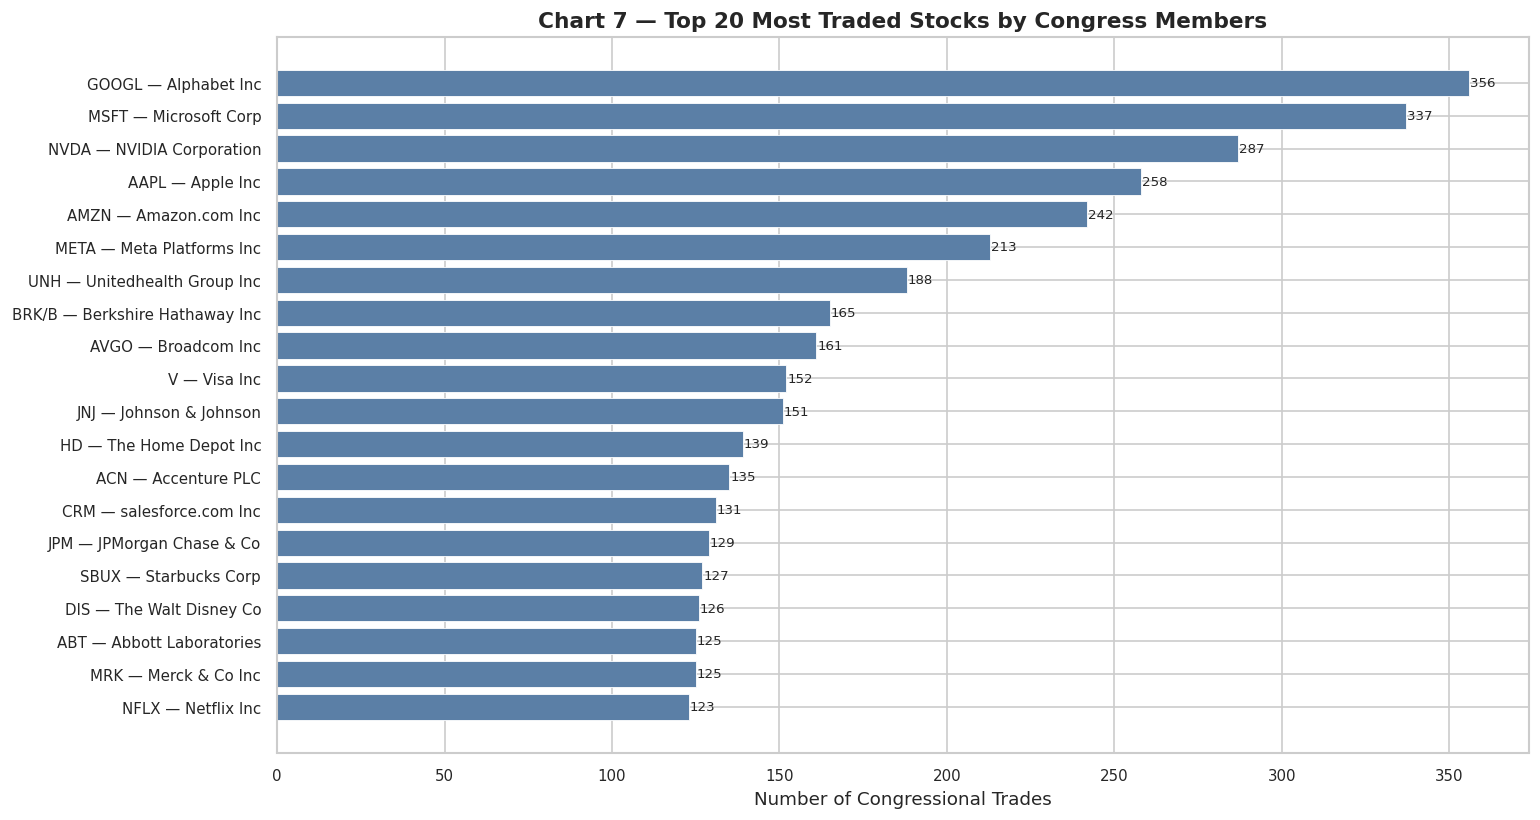

Chart 7 saved to: data/output/chart7_top_stocks.png


In [9]:
top_stocks = (
    trades.groupby(['ticker', 'company'])
    .size()
    .reset_index(name='trade_count')
    .sort_values('trade_count', ascending=False)
    .head(20)
)
 
fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(range(len(top_stocks)), top_stocks['trade_count'],
               color='#5B7FA6', edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top_stocks)))
ax.set_yticklabels([
    f"{row['ticker']} — {row['company'][:30]}"
    for _, row in top_stocks.iterrows()
], fontsize=9)
ax.set_xlabel("Number of Congressional Trades")
ax.set_title("Chart 7 — Top 20 Most Traded Stocks by Congress Members",
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
 
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va='center', fontsize=8)




plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart7_top_stocks.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 7 saved to: {out_path}")

# CELL 10 — Chart 8: Owner Type Distribution

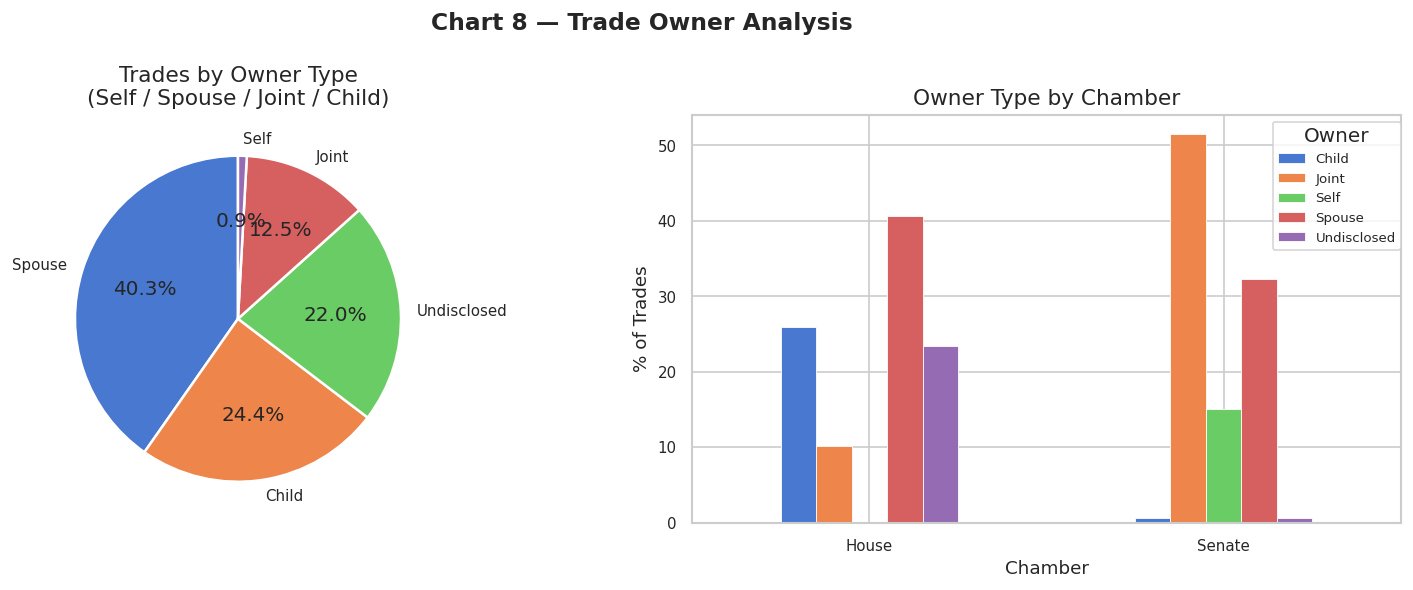

Chart 8 saved to: data/output/chart8_owner_type.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Chart 8 — Trade Owner Analysis", fontsize=14, fontweight='bold')
 
# Left: overall owner split
ax = axes[0]
owner_counts = trades['owner'].value_counts()
colors = sns.color_palette("muted", len(owner_counts))
ax.pie(owner_counts.values,
       labels=owner_counts.index,
       autopct='%1.1f%%',
       colors=colors,
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax.set_title("Trades by Owner Type\n(Self / Spouse / Joint / Child)")
 
# Right: owner type by chamber
ax2 = axes[1]
owner_chamber = trades.groupby(['chamber', 'owner']).size().unstack(fill_value=0)
owner_chamber_pct = owner_chamber.div(owner_chamber.sum(axis=1), axis=0) * 100
owner_chamber_pct.plot(kind='bar', ax=ax2,
                       edgecolor='white', linewidth=0.5)
ax2.set_xlabel("Chamber")
ax2.set_ylabel("% of Trades")
ax2.set_title("Owner Type by Chamber")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.legend(title="Owner", bbox_to_anchor=(1.01, 1), fontsize=8)
 



plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart8_owner_type.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 8 saved to: {out_path}")

# CELL 11 — Chart 9: Politician Trade Frequency Distribution


Politicians with >= 15 trades (qualify for Wilcoxon): 78
Politicians with < 15 trades (excluded from Wilcoxon): 72


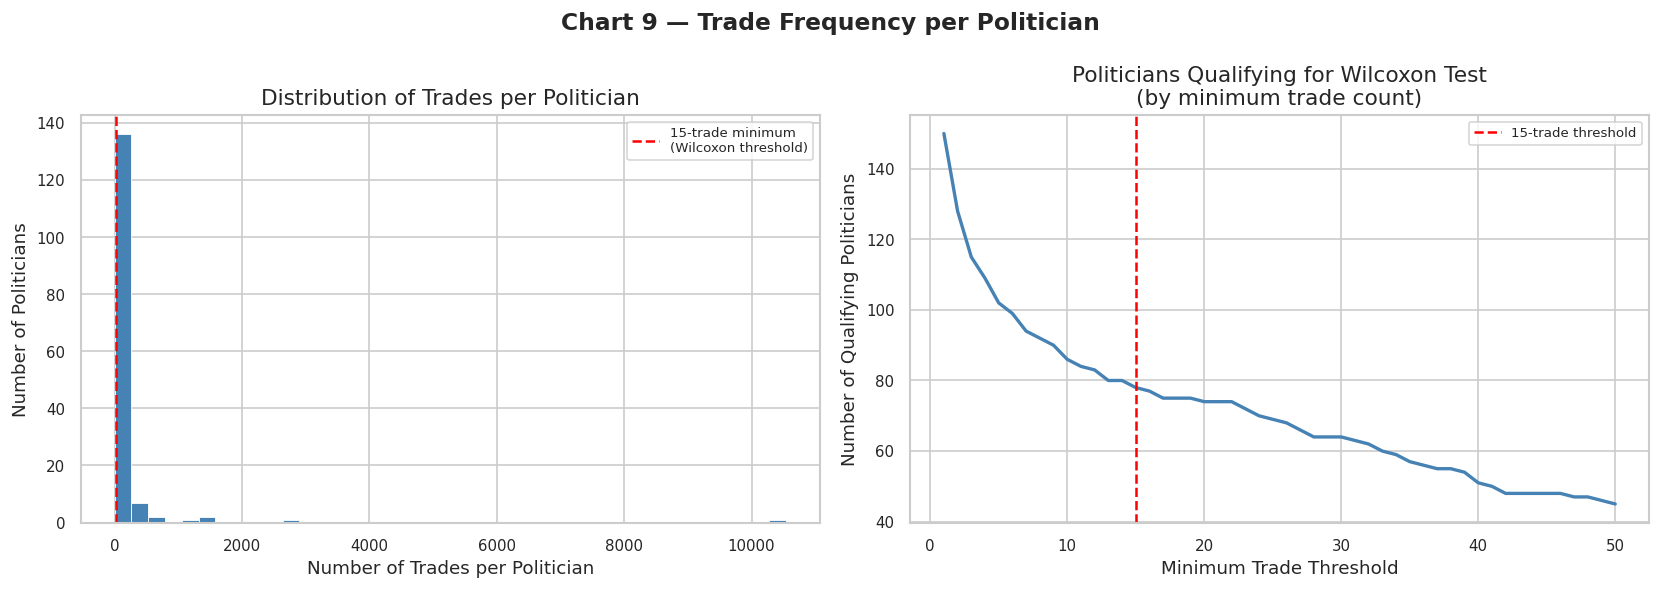

Chart 9 saved to: data/output/chart9_trade_frequency.png


In [13]:
trade_counts = trades.groupby('politician').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Chart 9 — Trade Frequency per Politician",
             fontsize=14, fontweight='bold')

# Left: histogram of trade counts per politician
ax = axes[0]
ax.hist(trade_counts.values, bins=40,
        color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(15, color='red', linestyle='--', linewidth=1.5,    
           label='15-trade minimum\n(Wilcoxon threshold)')      
ax.set_xlabel("Number of Trades per Politician")
ax.set_ylabel("Number of Politicians")
ax.set_title("Distribution of Trades per Politician")
ax.legend(fontsize=8)

# Right: cumulative — how many politicians qualify for Wilcoxon
ax2 = axes[1]
thresholds = range(1, 51)
qualifying = [(trade_counts >= t).sum() for t in thresholds]
ax2.plot(thresholds, qualifying, color='steelblue', linewidth=2)
ax2.axvline(15, color='red', linestyle='--', linewidth=1.5,       
            label='15-trade threshold')                             
ax2.set_xlabel("Minimum Trade Threshold")
ax2.set_ylabel("Number of Qualifying Politicians")
ax2.set_title("Politicians Qualifying for Wilcoxon Test\n(by minimum trade count)")
ax2.legend(fontsize=8)

qualifying_15 = (trade_counts >= 15).sum()                      
print(f"\nPoliticians with >= 15 trades (qualify for Wilcoxon): {qualifying_15}")   
print(f"Politicians with < 15 trades (excluded from Wilcoxon): {(trade_counts < 15).sum()}")  

plt.tight_layout()
out_path = os.path.join('data', 'output', 'chart9_trade_frequency.png')
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, bbox_inches='tight', dpi=150)
plt.show()
print(f"Chart 9 saved to: {out_path}")

# CELL 12 — Save EDA Summary Table

In [16]:
summary = {
    'Total qualifying trades':           len(trades),
    'Unique politicians':                 trades['politician'].nunique(),
    'Unique tickers':                     trades['ticker'].nunique(),
    'House trades':                       (trades['chamber'] == 'House').sum(),
    'Senate trades':                      (trades['chamber'] == 'Senate').sum(),
    'Buy trades':                         (trades['trade_type'] == 'BUY').sum(),
    'Sell trades':                        (trades['trade_type'] == 'SELL').sum(),
    'Median blind spot (days)':           trades['filed_after_days'].median(),
    'Mean blind spot (days)':             round(trades['filed_after_days'].mean(), 1),
    'Trades filed late (>45 days)':       (trades['filed_after_days'] > 45).sum(),
    'Politicians qualifying (>=15 trades)': (trade_counts >= 15).sum(),
    'Trade date range start':             trades['trade_date'].min().date(),
    'Trade date range end':               trades['trade_date'].max().date(),
}
 
summary_df = pd.DataFrame.from_dict(summary, orient='index', columns=['Value'])
summary_df.to_csv(OUTPUT_EDA)
 
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(summary_df.to_string())
print(f"\nSaved to {OUTPUT_EDA}")
print("\nNotebook 2 complete. Proceed to Notebook 3 (Feature Engineering).")

EDA SUMMARY
                                           Value
Total qualifying trades                    26566
Unique politicians                           150
Unique tickers                              1676
House trades                               24996
Senate trades                               1531
Buy trades                                 12312
Sell trades                                14254
Median blind spot (days)                    28.0
Mean blind spot (days)                      38.8
Trades filed late (>45 days)                2212
Politicians qualifying (>=15 trades)          78
Trade date range start                2023-04-17
Trade date range end                  2026-03-31

Saved to data/output/eda_summary.csv

Notebook 2 complete. Proceed to Notebook 3 (Feature Engineering).
